In [ ]:
!pip install langchainhub
!pip install langchain-openai
!pip install langchain
!pip install beautifulsoup4
!pip install langchain-community
!pip install faiss-cpu
!pip install -U langchain-community tavily-python
!pip gradio_client==0.2.10
!pip install gradio==3.38.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 58.6 MB/s eta 0:00:00
ERROR: unknown command "gradio_client==0.2.10"
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mdit-py-plugins to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of mdit-py-plugins to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backt

In [ ]:
import getpass
import os
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI
from langchain.chains import create_retrieval_chain

In [ ]:
os.environ["OPENAI_API_KEY"] = getpass.getpass()

··········


In [ ]:
os.environ["TAVILY_API_KEY"] = getpass.getpass()

··········


# Setup the retriver

In [ ]:
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader("https://docs.smith.langchain.com/")

docs = loader.load()

In [ ]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings()

In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter


text_splitter = RecursiveCharacterTextSplitter()
documents = text_splitter.split_documents(docs)
vector = FAISS.from_documents(documents, embeddings)

In [ ]:
from langchain.chains.combine_documents import create_stuff_documents_chain
# create_stuff_documents_chain :
#  Create a chain for passing a list of Documents to a model.

llm = ChatOpenAI(api_key=os.environ["OPENAI_API_KEY"])
output_parser = StrOutputParser()

prompt = ChatPromptTemplate.from_template("""Answer the following question based only on the provided context:

<context>
{context}
</context>

Question: {input}""", output_parser = output_parser)

document_chain = create_stuff_documents_chain(llm, prompt) # prompt | llm

In [ ]:
retriever = vector.as_retriever()
retrieval_chain = create_retrieval_chain(retriever, document_chain)

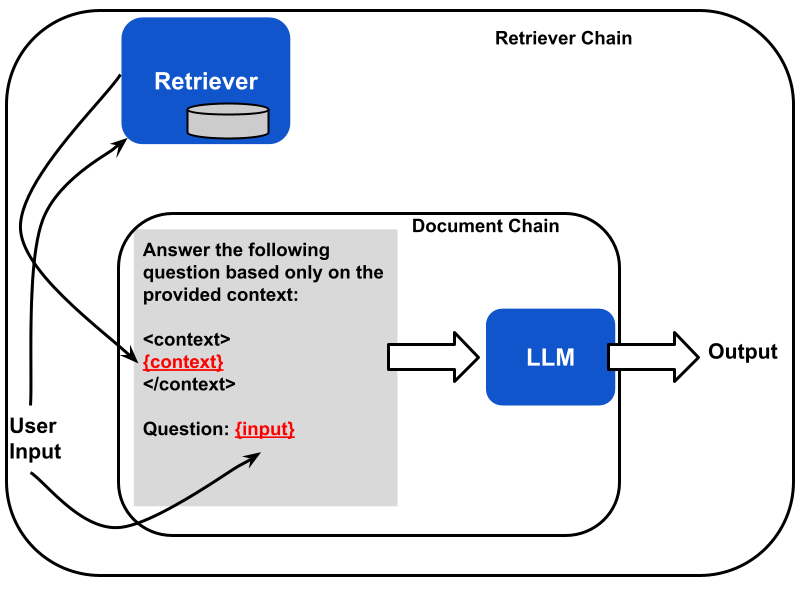

In [ ]:
retrieval_chain.invoke({"input": "What is LangSmith?"})

{'input': 'What is LangSmith?',
 'context': [Document(id='a0301c69-8202-426d-b9e7-38763665c6da', metadata={'source': 'https://docs.smith.langchain.com/', 'title': 'Get started with LangSmith | \uf8ffü¶úÔ∏è\uf8ffüõ†Ô∏è LangSmith', 'description': 'LangSmith is a platform for building production-grade LLM applications.', 'language': 'en'}, page_content="Get started with LangSmith | \uf8ffü¶úÔ∏è\uf8ffüõ†Ô∏è LangSmith\n\n\n\n\n\n\n\n\nSkip to main contentOur Building Ambient Agents with LangGraph course is now available on LangChain Academy!API ReferenceRESTPythonJS/TSSearchRegionUSEUGo to AppGet StartedObservabilityEvaluationPrompt EngineeringDeployment (LangGraph Platform)AdministrationSelf-hostingPricingReferenceCloud architecture and scalabilityAuthz and AuthnAuthentication methodsdata_formatsEvaluationDataset transformationsRegions FAQsdk_referenceGet StartedOn this pageGet started with LangSmith\nLangSmith is a platform for building production-grade LLM applications.\nIt allows you to

# Agents

In [ ]:
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "langsmith_search",
    "Search for information about LangSmith. For any questions about LangSmith, you must use this tool!",
)

# langsmith_search: Search for information about LangSmith. For any questions about LangSmith, you must use this tool!

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults

search = TavilySearchResults()

In [ ]:
print(search.description)
print(search.name)

A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. Input should be a search query.
tavily_search_results_json


In [ ]:
tools = [retriever_tool, search]

In [ ]:
from langchain_openai import ChatOpenAI
from langchain import hub
from langchain.agents import create_openai_functions_agent
from langchain.agents import AgentExecutor

# Get the prompt to use - you can modify this!
prompt = hub.pull("hwchase17/openai-functions-agent")

# You need to set OPENAI_API_KEY environment variable or pass it as argument `api_key`.
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)
agent = create_openai_functions_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

/usr/local/lib/python3.11/dist-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [ ]:
print(prompt)

input_variables=['agent_scratchpad', 'input'] optional_variables=['chat_history'] input_types={'chat_history': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langchain_core.messages.chat.ChatMessageChunk, Tag(tag='ChatMessageChunk')], typing.Annotated[langchain_core.messages.system.SystemMessageChunk, Tag(tag='SystemMessageChunk')]

In [ ]:
result = agent_executor.invoke({"input": "how can langsmith help with testing?"})



> Entering new AgentExecutor chain...

Invoking: `langsmith_search` with `{'query': 'how can LangSmith help with testing'}`


Get started with LangSmith | ü¶úÔ∏èüõ†Ô∏è LangSmith








Skip to main contentOur Building Ambient Agents with LangGraph course is now available on LangChain Academy!API ReferenceRESTPythonJS/TSSearchRegionUSEUGo to AppGet StartedObservabilityEvaluationPrompt EngineeringDeployment (LangGraph Platform)AdministrationSelf-hostingPricingReferenceCloud architecture and scalabilityAuthz and AuthnAuthentication methodsdata_formatsEvaluationDataset transformationsRegions FAQsdk_referenceGet StartedOn this pageGet started with LangSmith
LangSmith is a platform for building production-grade LLM applications.
It allows you to closely monitor and evaluate your application, so you can ship quickly and with confidence.
ObservabilityAnalyze traces in LangSmith and configure metrics, dashboards, alerts based on these.EvalsEvaluate your application over production traffic 

In [ ]:
print(result["output"])

LangSmith can help with testing in the following ways:

1. **Observability**: LangSmith provides LLM-native observability, allowing you to get meaningful insights from your application. This feature covers all stages of application development, from prototyping to beta testing to production. You can analyze traces in LangSmith, configure metrics, dashboards, and alerts based on these observations.

2. **Evaluations**: LangSmith offers tools to build and run high-quality evaluations easily. You can assess the performance of your application using off-the-shelf evaluators, analyze evaluation results in the LangSmith UI, and compare results over time. Additionally, you can collect human feedback on your data to improve your application.

3. **Prompt Engineering**: AI applications involve writing prompts to instruct the LLM on what to do. LangSmith provides tools for prompt engineering, enabling you to find the perfect prompt for your application. You can iterate on models and prompts usin

In [ ]:
result = agent_executor.invoke({"input": "what is the weather in SF?"})



> Entering new AgentExecutor chain...

Invoking: `tavily_search_results_json` with `{'query': 'weather in San Francisco'}`


[{'title': 'Weather in San Francisco in February 2025 (California)', 'url': 'https://world-weather.info/forecast/usa/san_francisco/february-2025/', 'content': "1 +59° +55°\n   2 +59° +59°\n   3 +61° +57°\n   4 +59° +57°\n   5 +55° +46°\n   6 +59° +46°\n   7 +55° +52°\n   8 +55° +46°\n   9 +55° +45°\n   10 +55° +43°\n   11 +52° +43°\n   12 +54° +45°\n   13 +57° +52°\n   14 +55° +54°\n   15 +57° +45°\n   16 +57° +48°\n   17 +57° +50°\n   18 +59° +48°\n   19 +59° +50°\n   20 +63° +48°\n   21 +63° +46°\n   22 +59° +46°\n   23 +61° +50°\n   24 +61° +54°\n   25 +63° +52°\n   26 +68° +48°\n   27 +70° +50°\n   28 +66° +54° [...] San Rafael+59°\n\nSan Ramon+61°\n\nSouth San Francisco+55°\n\nVallejo+55°\n\nPalo Alto+59°\n\nPacifica+54°\n\nBerkeley+55°\n\nCastro Valley+57°\n\nConcord+66°\n\nDaly City+54°\n\nSouth Vallejo+55°\n\nSheffield Village+57°\n\nMinimum and maximum

In [ ]:
print(result["output"])

The weather in San Francisco today is around 55°F with a high of 55°F and a low of 52°F. You can find more detailed information about the weather in San Francisco on [this website](https://world-weather.info/forecast/usa/san_francisco/february-2025/).


# Gradio: Quickly Build & Share ML Apps ... or ot be more accurate PoCs

In [ ]:
import gradio as gr

In [ ]:
def predict(message, _):
  result = agent_executor.invoke({"input": message})
  return result["output"]

In [ ]:
gr.ChatInterface(predict,
    chatbot=gr.Chatbot(height=300),
    textbox=gr.Textbox(placeholder="Hi I am your virtual assistant, how can I help you today?", container=False, scale=7),
    title="DocumentQABot",
    theme="soft",
    examples=["What is the weather like in SF?", "What is LangSmith?"],
    retry_btn=None,
    undo_btn="Delete Previous",
    clear_btn="Clear",).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
IMPORTANT: You are using gradio version 3.38.0, however version 4.44.1 is available, please upgrade.
--------
Running on public URL: https://7c7ca2c047aaa99ebc.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


# More on Tools

In [ ]:
from langchain_core.tools import tool

In [ ]:
## Add two more tools that perform addition and exponentiation
@tool
def multiply(first_int: int, second_int: int) -> int:
    """Multiply two integers together."""
    return first_int * second_int

@tool
def add(first_int: int, second_int: int) -> int:
    "Add two integers."
    return first_int + second_int


@tool
def exponentiate(base: int, exponent: int) -> int:
    "Exponentiate the base to the exponent power."
    return base**exponent

In [ ]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Multiply two integers together.
{'first_int': {'title': 'First Int', 'type': 'integer'}, 'second_int': {'title': 'Second Int', 'type': 'integer'}}


In [ ]:
multiply.invoke({"first_int": 4, "second_int": 5})

20

In [ ]:
from langchain.tools.render import render_text_description

rendered_tools = render_text_description([multiply])
print(rendered_tools)

multiply(first_int: int, second_int: int) -> int - Multiply two integers together.
